In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D


from Greedy_SOSP import Greedy_SOSP
from utils.generate_graph import generate_graph

# incrementing node sizes twice the previous
NODE_SIZES = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
EDGE_PROBS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]  # edge probablity for nodes
REPEAT = 10  # repetation of 10


results = []  # for storing ablation results
# total no of running exp.
total_runs = len(NODE_SIZES)*len(EDGE_PROBS) * REPEAT

with tqdm(total=total_runs) as pbar:
    for n in NODE_SIZES:
        for prob in EDGE_PROBS:
            for r in range(REPEAT):
                # for each node having all the prob generate graph
                G = generate_graph(n, prob)

                # for each node and edge probablity, checking performance of greedy_sosp_update
                start = time.perf_counter()  # starting runtime
                Greedy_SOSP(G)  # greedy sosp algorithm running
                end = time.perf_counter()  # ending runtime
                runtime = end - start  # total runtime by algo

                # storing results
                results.append({
                    "nodes": n,
                    "edge_prob": prob,
                    "runtime": runtime
                })

                pbar.update(1)  # for updating tqdm


 63%|██████▎   | 338/540 [00:10<00:11, 17.06it/s]  

In [1]:
df = pd.DataFrame(results)
df.to_csv('Greedy_SOSP_results.csv',  index=False)

NameError: name 'pd' is not defined

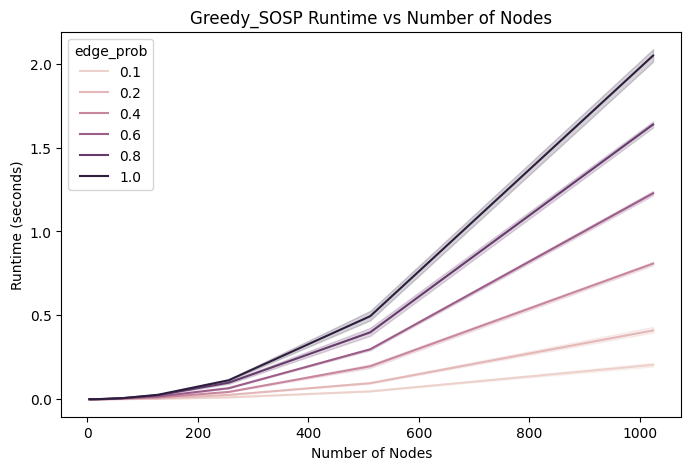

In [4]:
# run time vs nodes plot
plt.figure(figsize=(8, 5))

sns.lineplot(data=df,
             x="nodes",
             y="runtime",
             hue="edge_prob",
             estimator="mean")

plt.title("Greedy_SOSP Runtime vs Number of Nodes")
plt.xlabel("Number of Nodes")
plt.ylabel("Runtime (seconds)")

plt.show()


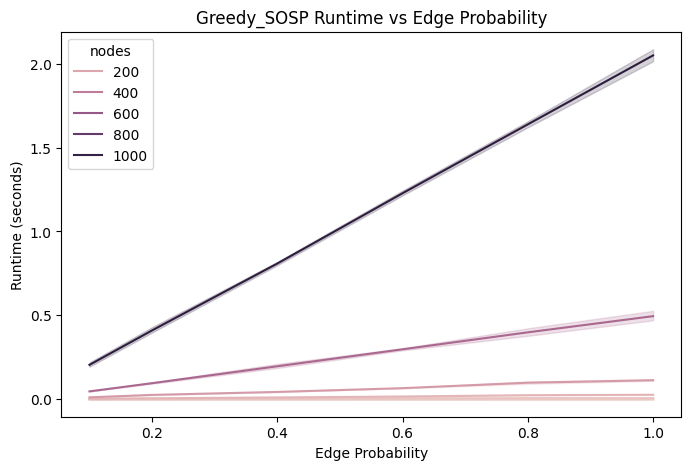

In [5]:
# runtime vs edge probablity
plt.figure(figsize=(8, 5))

sns.lineplot(data=df,
             x="edge_prob",
             y="runtime",
             hue="nodes",
             estimator="mean")

plt.title("Greedy_SOSP Runtime vs Edge Probability")
plt.xlabel("Edge Probability")
plt.ylabel("Runtime (seconds)")

plt.show()

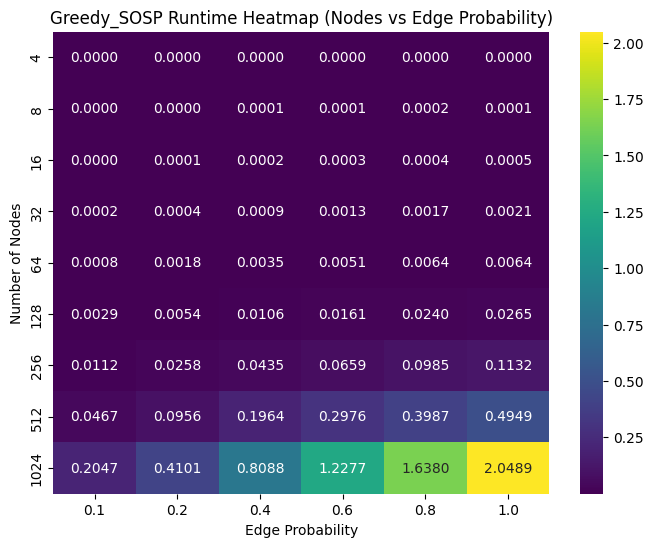

In [6]:
# heatmap n vs e
pivot = df.pivot_table(values="runtime",
                       index="nodes",
                       columns="edge_prob",
                       aggfunc=np.mean)

plt.figure(figsize=(8, 6))

sns.heatmap(pivot,
            annot=True,
            fmt=".4f",
            cmap="viridis")

plt.title("Greedy_SOSP Runtime Heatmap (Nodes vs Edge Probability)")
plt.xlabel("Edge Probability")
plt.ylabel("Number of Nodes")

plt.show()

In [1]:

# # a 3D representation of nodes, edge probablity and runtime

# pivot = df.pivot_table(
#     values="runtime",
#     index="nodes",
#     columns="edge_prob",
#     aggfunc=np.mean
# )

# nodes = pivot.index.values
# edge_probs = pivot.columns.values

# X, Y = np.meshgrid(edge_probs, nodes)
# Z = pivot.values

# # X -> edge probablity
# # Y -> node counts
# # Z -> runtime


# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')

# surface = ax.plot_surface(
#     X, Y, Z,
#     cmap='viridis',
#     edgecolor='k',
#     alpha=0.9
# )

# ax.set_xlabel("Edge Probability (p)")
# ax.set_ylabel("Number of Nodes (n)")
# ax.set_zlabel("Runtime (seconds)")
# ax.set_title("Greedy_SOSP Runtime Surface")
# fig.colorbar(surface, shrink=0.5, aspect=10)
# # plt.savefig("runtime_surface_plot.png", dpi=300, bbox_inches="tight")

# plt.show()

# # Greedy_SOSP_Update Runtime Surface interpretation
# # surface rises as nodes increases
# # surface rises as edge probablity increases
# # highest peak occurs as p = 1.0 and n = 1024


C:\Users\hp\AppData\Local\Temp\ipykernel_22116\4146221721.py:90: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


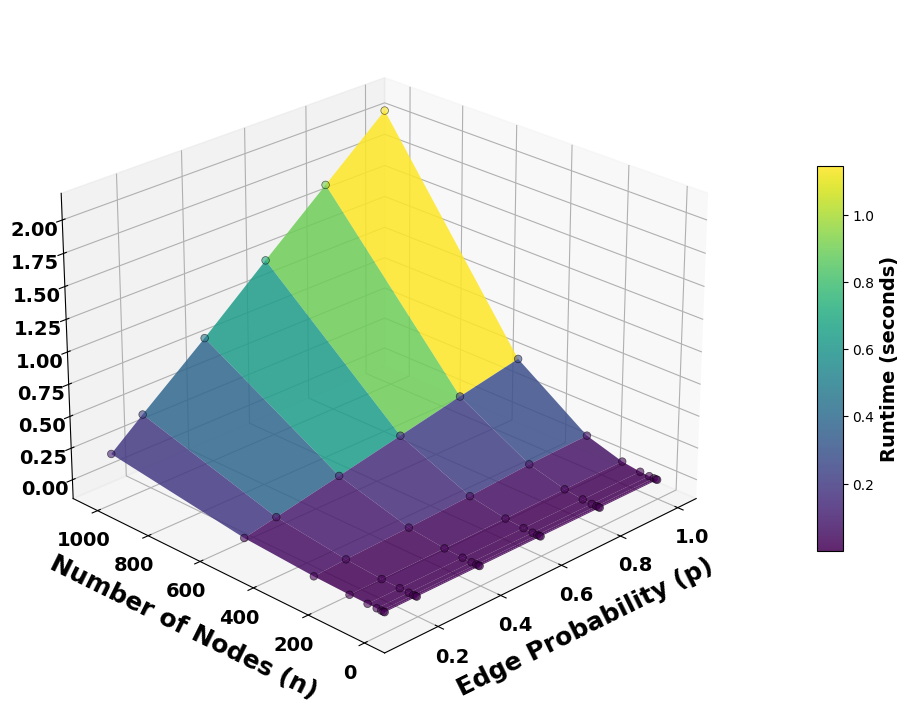


=== Greedy_SOSP Runtime Analysis Summary ===

Runtime Statistics:
Minimum Runtime: 6.90e-06 seconds
Maximum Runtime: 2.15e+00 seconds
Mean Runtime: 1.55e-01 seconds

Runtimes by Number of Nodes:
            min       max      mean
nodes                              
4      0.000008  0.000091  0.000031
8      0.000007  0.000502  0.000075
16     0.000018  0.000542  0.000276
32     0.000086  0.002105  0.001092
64     0.000619  0.006928  0.004015
128    0.002695  0.033144  0.014244
256    0.010864  0.138974  0.059671
512    0.046143  0.582643  0.254968
1024   0.187771  2.149614  1.056377

Runtimes by Edge Probability:
                min       max      mean
edge_prob                              
0.1        0.000007  0.245999  0.029627
0.2        0.000007  0.494989  0.059921
0.4        0.000008  0.834565  0.118212
0.6        0.000018  1.272439  0.179339
0.8        0.000026  1.694471  0.240880
1.0        0.000037  2.149614  0.299188


In [1]:
# 3D Visualization: Runtime as a function of Edge Probability and Number of Nodes
# Suitable for research article

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Read the CSV file
df_results = pd.read_csv('Greedy_SOSP_results.csv')

# Create pivot table for surface plot
pivot = df_results.pivot_table(
    values="runtime",
    index="nodes",
    columns="edge_prob",
    aggfunc=np.mean
)

nodes = pivot.index.values
edge_probs = pivot.columns.values

# Create meshgrid
X, Y = np.meshgrid(edge_probs, nodes)
Z = pivot.values

# Create 3D surface plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot surface with enhanced styling
surface = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    edgecolor='none',
    alpha=0.85,
    linewidth=0,
    antialiased=True,
    rstride=1,
    cstride=1
)

# Add scatter points on the surface for emphasis
scatter = ax.scatter(
    X, Y, Z,
    c=Z,
    cmap='viridis',
    s=30,
    alpha=0.6,
    edgecolor='black',
    linewidth=0.5
)

# Set labels with proper font sizing
ax.set_xlabel('Edge Probability (p)', fontsize=18, labelpad=10, fontweight='heavy')
ax.set_ylabel('Number of Nodes (n)', fontsize=18, labelpad=10, fontweight='heavy')
ax.set_zlabel('Runtime (seconds)', fontsize=18, labelpad=15, fontweight='heavy')
# ax.set_title('Greedy_SOSP Runtime Analysis\n3D Surface Plot', 
#              fontsize=14, fontweight='bold', pad=20)

# Customize tick labels
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='z', labelsize=14)

# Set tick label font weight to bold
for label in ax.get_xticklabels():
    label.set_weight('heavy')
for label in ax.get_yticklabels():
    label.set_weight('heavy')
for label in ax.get_zticklabels():
    label.set_weight('heavy')
    label.set_fontsize(14)





# Add colorbar
cbar = fig.colorbar(surface, shrink=0.5, aspect=15, pad=0.1)
cbar.set_label('Runtime (seconds)', fontsize=14, fontweight='bold')

# Set viewing angle for better visualization
ax.view_init(elev=25, azim=225)

# Add grid
ax.grid(True, alpha=0.3)

# Tight layout
plt.tight_layout()

# Save high-quality version for research article
plt.savefig('Greedy_SOSP_3D_Runtime_Analysis.pdf', dpi=600, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n=== Greedy_SOSP Runtime Analysis Summary ===")
print(f"\nRuntime Statistics:")
print(f"Minimum Runtime: {df_results['runtime'].min():.2e} seconds")
print(f"Maximum Runtime: {df_results['runtime'].max():.2e} seconds")
print(f"Mean Runtime: {df_results['runtime'].mean():.2e} seconds")
print(f"\nRuntimes by Number of Nodes:")
print(df_results.groupby('nodes')['runtime'].agg(['min', 'max', 'mean']))
print(f"\nRuntimes by Edge Probability:")
print(df_results.groupby('edge_prob')['runtime'].agg(['min', 'max', 'mean']))